In [3]:
import pandas as pd
from pathlib import Path

# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "Tableau BlinkIT Grocery Project U16955293080 (4).xlsx"

# Load raw dataset
df = pd.read_excel(RAW_FILE)

print(f"Dataset shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (8523, 12)

Columns:
['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']


In [4]:
print("Data Types:")
print(df.dtypes)

Data Types:
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object


In [5]:
missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64


In [6]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


In [7]:
categorical_columns = [
    "Item_Fat_Content",
    "Item_Type",
    "Outlet_Size",
    "Outlet_Location_Type",
    "Outlet_Type"
]

for col in categorical_columns:
    print(f"\n{'='*50}")
    print(f"{col}")
    print(df[col].value_counts(dropna=False))
    


Item_Fat_Content
Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

Item_Type
Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Outlet_Size
Outlet_Size
Medium    2793
NaN       2410
Small     2388
High       932
Name: count, dtype: int64

Outlet_Location_Type
Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

Outlet_Type
Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supe

In [8]:
numeric_columns = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Item_Outlet_Sales"
]

print(df[numeric_columns].describe().T)

                            count         mean          std       min   
Item_Weight                7060.0    12.857645     4.643456     4.555  \
Item_Visibility            8523.0     0.066132     0.051598     0.000   
Item_MRP                   8523.0   140.992782    62.275067    31.290   
Outlet_Establishment_Year  8523.0  1997.831867     8.371760  1985.000   
Item_Outlet_Sales          8523.0  2181.288914  1706.499616    33.290   

                                   25%          50%          75%           max  
Item_Weight                   8.773750    12.600000    16.850000     21.350000  
Item_Visibility               0.026989     0.053931     0.094585      0.328391  
Item_MRP                     93.826500   143.012800   185.643700    266.888400  
Outlet_Establishment_Year  1987.000000  1999.000000  2004.000000   2009.000000  
Item_Outlet_Sales           834.247400  1794.331000  3101.296400  13086.964800  


In [9]:
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

print(df["Item_Fat_Content"].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [10]:
weight_missing_by_type = (
    df[df["Item_Weight"].isna()]
    .groupby("Item_Type")
    .size()
    .sort_values(ascending=False)
)

print(weight_missing_by_type)

Item_Type
Fruits and Vegetables    213
Snack Foods              212
Household                151
Frozen Foods             138
Dairy                    116
Baking Goods             112
Canned                   110
Health and Hygiene        90
Meat                      88
Soft Drinks               71
Breads                    47
Others                    32
Hard Drinks               31
Breakfast                 21
Starchy Foods             18
Seafood                   13
dtype: int64


In [11]:
# Check whether each missing weight has a known weight
item_weight_reference = (
    df.groupby("Item_Identifier")["Item_Weight"]
    .transform("median")
)

recoverable = df["Item_Weight"].isna() & item_weight_reference.notna()

print(f"Missing weights: {df['Item_Weight'].isna().sum()}")
print(f"Recoverable using Item_Identifier: {recoverable.sum()}")
print(f"Not recoverable using Item_Identifier: {(df['Item_Weight'].isna() & item_weight_reference.isna()).sum()}")


Missing weights: 1463
Recoverable using Item_Identifier: 1459
Not recoverable using Item_Identifier: 4


In [13]:
# 1. Fill using the median weight of the same Item_Identifier
item_weight_median = (
    df.groupby("Item_Identifier")["Item_Weight"]
    .transform("median")
)

df["Item_Weight"] = df["Item_Weight"].fillna(item_weight_median)

# 2. Fallback: fill remaining missing values using Item_Type median
item_type_weight_median = (
    df.groupby("Item_Type")["Item_Weight"]
    .transform("median")
)

df["Item_Weight"] = df["Item_Weight"].fillna(item_type_weight_median)

# 3. Validation
print("Remaining missing Item_Weight:", df["Item_Weight"].isna().sum())
print("Dataset shape:", df.shape)


Remaining missing Item_Weight: 0
Dataset shape: (8523, 12)


In [14]:
outlet_size_check = (
    df.groupby("Outlet_Identifier")["Outlet_Size"]
    .agg(lambda x: x.dropna().unique().tolist())
)

print(outlet_size_check)

Outlet_Identifier
OUT010          []
OUT013      [High]
OUT017          []
OUT018    [Medium]
OUT019     [Small]
OUT027    [Medium]
OUT035     [Small]
OUT045          []
OUT046     [Small]
OUT049    [Medium]
Name: Outlet_Size, dtype: object


In [15]:
outlet_info = (
    df.groupby("Outlet_Identifier")
    .agg(
        Outlet_Type=("Outlet_Type", "first"),
        Outlet_Location_Type=("Outlet_Location_Type", "first"),
        Outlet_Size=("Outlet_Size", lambda x: x.dropna().unique().tolist())
    )
)

print(outlet_info)

                         Outlet_Type Outlet_Location_Type Outlet_Size
Outlet_Identifier                                                    
OUT010                 Grocery Store               Tier 3          []
OUT013             Supermarket Type1               Tier 3      [High]
OUT017             Supermarket Type1               Tier 2          []
OUT018             Supermarket Type2               Tier 3    [Medium]
OUT019                 Grocery Store               Tier 1     [Small]
OUT027             Supermarket Type3               Tier 3    [Medium]
OUT035             Supermarket Type1               Tier 2     [Small]
OUT045             Supermarket Type1               Tier 2          []
OUT046             Supermarket Type1               Tier 1     [Small]
OUT049             Supermarket Type1               Tier 1    [Medium]


In [16]:
# Fill missing Outlet_Size based on matching outlet characteristics
outlet_size_mapping = {
    "OUT010": "Small",
    "OUT017": "Small",
    "OUT045": "Small"
}

df["Outlet_Size"] = df["Outlet_Identifier"].map(
    outlet_size_mapping
).fillna(df["Outlet_Size"])

# Validation
print("Remaining missing Outlet_Size:", df["Outlet_Size"].isna().sum())
print("\nOutlet_Size distribution:")
print(df["Outlet_Size"].value_counts())

print("\nDataset shape:", df.shape)

Remaining missing Outlet_Size: 0

Outlet_Size distribution:
Outlet_Size
Small     4798
Medium    2793
High       932
Name: count, dtype: int64

Dataset shape: (8523, 12)


In [17]:
print("========== FINAL DATA VALIDATION ==========")

print("\n1. Dataset shape:")
print(df.shape)

print("\n2. Missing values:")
print(df.isnull().sum())

print("\n3. Duplicate rows:")
print(df.duplicated().sum())

print("\n4. Item Fat Content:")
print(df["Item_Fat_Content"].value_counts())

print("\n5. Outlet Size:")
print(df["Outlet_Size"].value_counts())

print("\n6. Numeric summary:")
print(df[[
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Item_Outlet_Sales"
]].describe().T)

========== FINAL DATA VALIDATION ==========

1. Dataset shape:
(8523, 12)

2. Missing values:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64

3. Duplicate rows:
0

4. Item Fat Content:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

5. Outlet Size:
Outlet_Size
Small     4798
Medium    2793
High       932
Name: count, dtype: int64

6. Numeric summary:
                    count         mean          std     min         25%   
Item_Weight        8523.0    12.875361     4.645031   4.555    8.785000  \
Item_Visibility    8523.0     0.066132     0.051598   0.000    0.026989   
Item_MRP           8523.0   140.992782    62.275067  31.

In [18]:
from pathlib import Path

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_FILE = PROCESSED_DIR / "blinkit_analysis_ready.csv"

df.to_csv(PROCESSED_FILE, index=False)

print(f"Saved: {PROCESSED_FILE}")
print(f"Shape: {df.shape}")

Saved: c:\Users\PRABHAT RISHI\BlinkIT-Performance-Analytics\data\processed\blinkit_analysis_ready.csv
Shape: (8523, 12)


In [19]:
# Re-load the processed CSV from disk
processed_df = pd.read_csv(PROCESSED_FILE)

print("Processed dataset shape:", processed_df.shape)

print("\nMissing values:")
print(processed_df.isnull().sum().sum())

print("\nDuplicate rows:")
print(processed_df.duplicated().sum())

print("\nFat content:")
print(processed_df["Item_Fat_Content"].value_counts())

print("\nOutlet size:")
print(processed_df["Outlet_Size"].value_counts())

Processed dataset shape: (8523, 12)

Missing values:
0

Duplicate rows:
0

Fat content:
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

Outlet size:
Outlet_Size
Small     4798
Medium    2793
High       932
Name: count, dtype: int64


In [20]:
# Core business KPIs
kpis = {
    "Total Sales": processed_df["Item_Outlet_Sales"].sum(),
    "Total Records": len(processed_df),
    "Unique Items": processed_df["Item_Identifier"].nunique(),
    "Unique Outlets": processed_df["Outlet_Identifier"].nunique(),
    "Average Sales": processed_df["Item_Outlet_Sales"].mean(),
    "Average MRP": processed_df["Item_MRP"].mean(),
    "Average Rating": None,  # Rating is not present in this dataset
}

for metric, value in kpis.items():
    if value is None:
        print(f"{metric}: Not available in this dataset")
    elif isinstance(value, float):
        print(f"{metric}: {value:,.2f}")
    else:
        print(f"{metric}: {value:,}")

Total Sales: 18,591,125.41
Total Records: 8,523
Unique Items: 1,559
Unique Outlets: 10
Average Sales: 2,181.29
Average MRP: 140.99
Average Rating: Not available in this dataset


In [21]:
# Main business breakdowns

print("========== SALES BY ITEM TYPE ==========")
print(
    processed_df.groupby("Item_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY OUTLET TYPE ==========")
print(
    processed_df.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY LOCATION ==========")
print(
    processed_df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY FAT CONTENT ==========")
print(
    processed_df.groupby("Item_Fat_Content")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print("\n========== SALES BY ESTABLISHMENT YEAR ==========")
print(
    processed_df.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"]
    .sum()
    .sort_index()
)

========== SALES BY ITEM TYPE ==========
Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Canned                   1.444151e+06
Baking Goods             1.265525e+06
Health and Hygiene       1.045200e+06
Meat                     9.175656e+05
Soft Drinks              8.928977e+05
Breads                   5.532372e+05
Hard Drinks              4.577934e+05
Starchy Foods            3.514013e+05
Others                   3.255176e+05
Breakfast                2.322990e+05
Seafood                  1.488682e+05
Name: Item_Outlet_Sales, dtype: float64

========== SALES BY OUTLET TYPE ==========
Outlet_Type
Supermarket Type1    1.291734e+07
Supermarket Type3    3.453926e+06
Supermarket Type2    1.851823e+06
Grocery Store        3.680343e+05
Name: Item_Outlet_Sales, dtype: float64

========== SALES BY LOCATION ==========
Outlet_Location_Type
Tier 3 

In [23]:
top_10_items = (
    processed_df.groupby("Item_Identifier")
    .agg(
        Total_Sales=("Item_Outlet_Sales", "sum"),
        Avg_MRP=("Item_MRP", "mean"),
        Records=("Item_Identifier", "size")
    )
    .sort_values("Total_Sales", ascending=False)
    .head(10)
)

print(top_10_items)

                 Total_Sales     Avg_MRP  Records
Item_Identifier                                  
FDY55             42661.8008  257.273800        8
FDA15             41584.5364  249.496700        8
FDZ20             40185.0248  254.110600        8
FDF05             36555.7490  262.891000        8
FDA04             35741.4756  259.008700        8
FDK03             34843.9772  255.064171        7
NCQ06             34680.1904  254.968067        9
NCQ53             34508.4140  236.501857        7
FDJ55             33531.0196  224.727900        8
FDD44             32723.4042  257.647933        6


In [24]:
outlet_performance = (
    processed_df.groupby("Outlet_Identifier")
    .agg(
        Total_Sales=("Item_Outlet_Sales", "sum"),
        Avg_Sales=("Item_Outlet_Sales", "mean"),
        Records=("Item_Identifier", "size"),
        Outlet_Type=("Outlet_Type", "first"),
        Outlet_Size=("Outlet_Size", "first"),
        Location=("Outlet_Location_Type", "first"),
        Establishment_Year=("Outlet_Establishment_Year", "first")
    )
    .sort_values("Total_Sales", ascending=False)
)

print(outlet_performance)

                    Total_Sales    Avg_Sales  Records        Outlet_Type   
Outlet_Identifier                                                          
OUT027             3.453926e+06  3694.038558      935  Supermarket Type3  \
OUT035             2.268123e+06  2438.841866      930  Supermarket Type1   
OUT049             2.183970e+06  2348.354635      930  Supermarket Type1   
OUT017             2.167465e+06  2340.675263      926  Supermarket Type1   
OUT013             2.142664e+06  2298.995256      932  Supermarket Type1   
OUT046             2.118395e+06  2277.844267      930  Supermarket Type1   
OUT045             2.036725e+06  2192.384798      929  Supermarket Type1   
OUT018             1.851823e+06  1995.498739      928  Supermarket Type2   
OUT010             1.883402e+05   339.351662      555      Grocery Store   
OUT019             1.796941e+05   340.329723      528      Grocery Store   

                  Outlet_Size Location  Establishment_Year  
Outlet_Identifier         

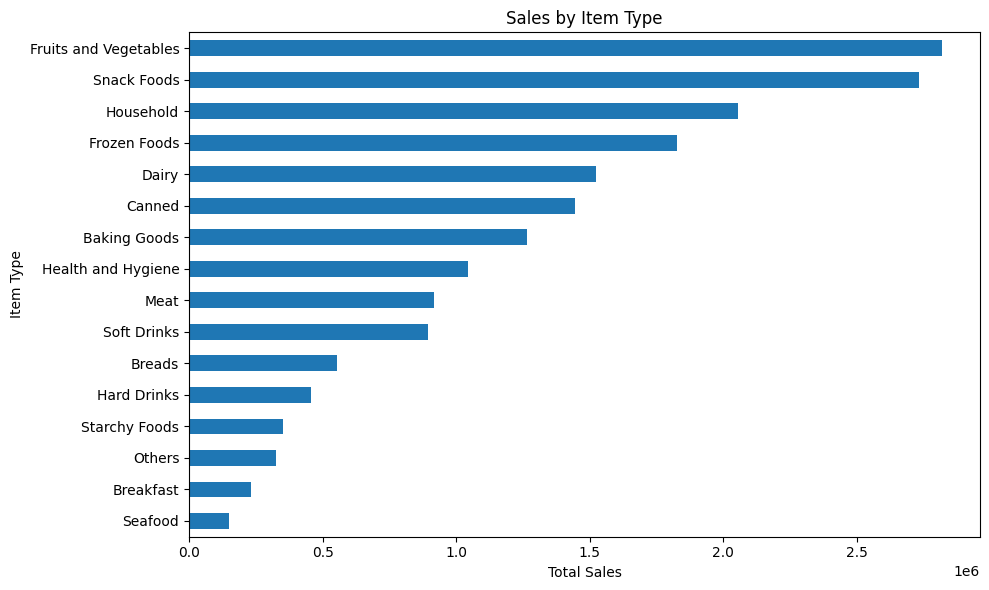

In [25]:
import matplotlib.pyplot as plt

sales_by_type = (
    processed_df.groupby("Item_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
sales_by_type.plot(kind="barh")
plt.title("Sales by Item Type")
plt.xlabel("Total Sales")
plt.ylabel("Item Type")
plt.tight_layout()
plt.savefig("../visuals/01_sales_by_item_type.png", dpi=300, bbox_inches="tight")
plt.show()

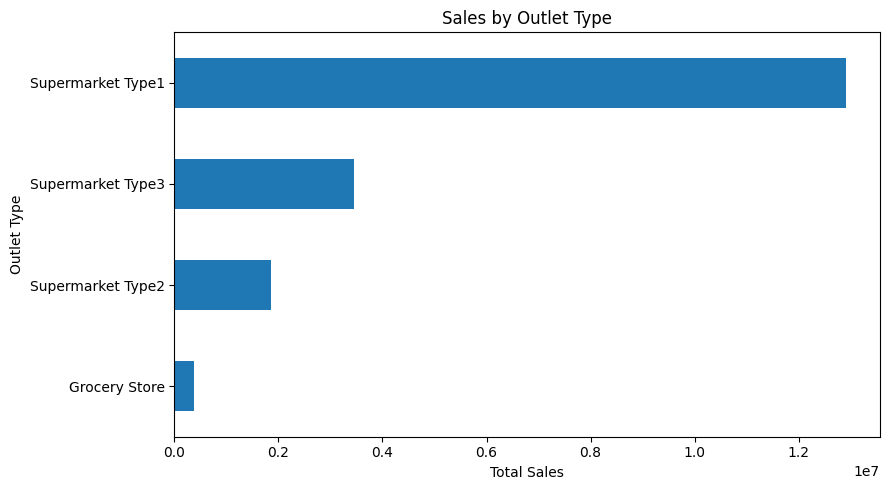

In [26]:
sales_by_outlet_type = (
    processed_df.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
sales_by_outlet_type.plot(kind="barh")
plt.title("Sales by Outlet Type")
plt.xlabel("Total Sales")
plt.ylabel("Outlet Type")
plt.tight_layout()
plt.savefig("../visuals/02_sales_by_outlet_type.png", dpi=300, bbox_inches="tight")
plt.show()

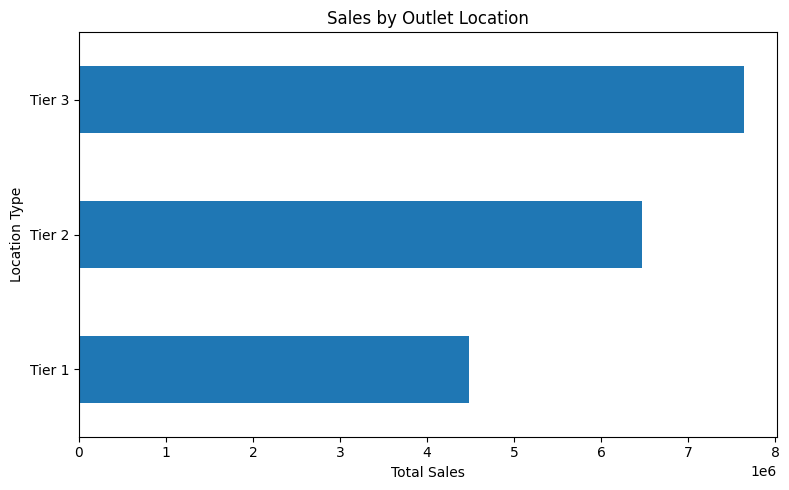

In [27]:
sales_by_location = (
    processed_df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
sales_by_location.plot(kind="barh")
plt.title("Sales by Outlet Location")
plt.xlabel("Total Sales")
plt.ylabel("Location Type")
plt.tight_layout()
plt.savefig("../visuals/03_sales_by_location.png", dpi=300, bbox_inches="tight")
plt.show()

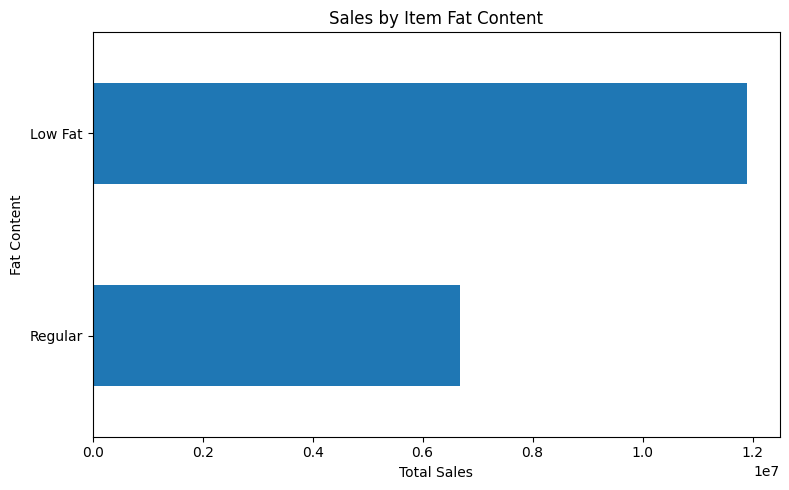

In [28]:
sales_by_fat = (
    processed_df.groupby("Item_Fat_Content")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
sales_by_fat.plot(kind="barh")
plt.title("Sales by Item Fat Content")
plt.xlabel("Total Sales")
plt.ylabel("Fat Content")
plt.tight_layout()
plt.savefig("../visuals/04_sales_by_fat_content.png", dpi=300, bbox_inches="tight")
plt.show()

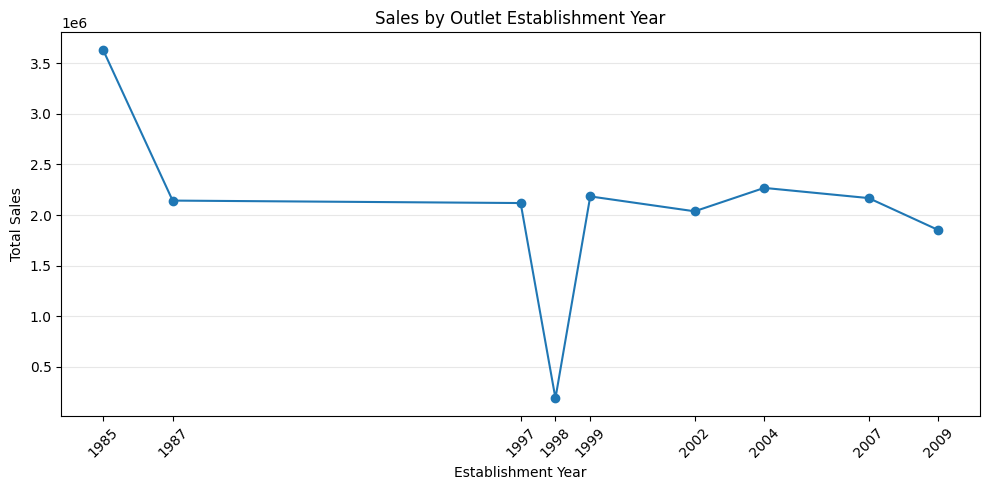

In [29]:
sales_by_year = (
    processed_df.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(10, 5))
sales_by_year.plot(kind="line", marker="o")
plt.title("Sales by Outlet Establishment Year")
plt.xlabel("Establishment Year")
plt.ylabel("Total Sales")
plt.xticks(sales_by_year.index, rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../visuals/05_sales_by_establishment_year.png", dpi=300, bbox_inches="tight")
plt.show()

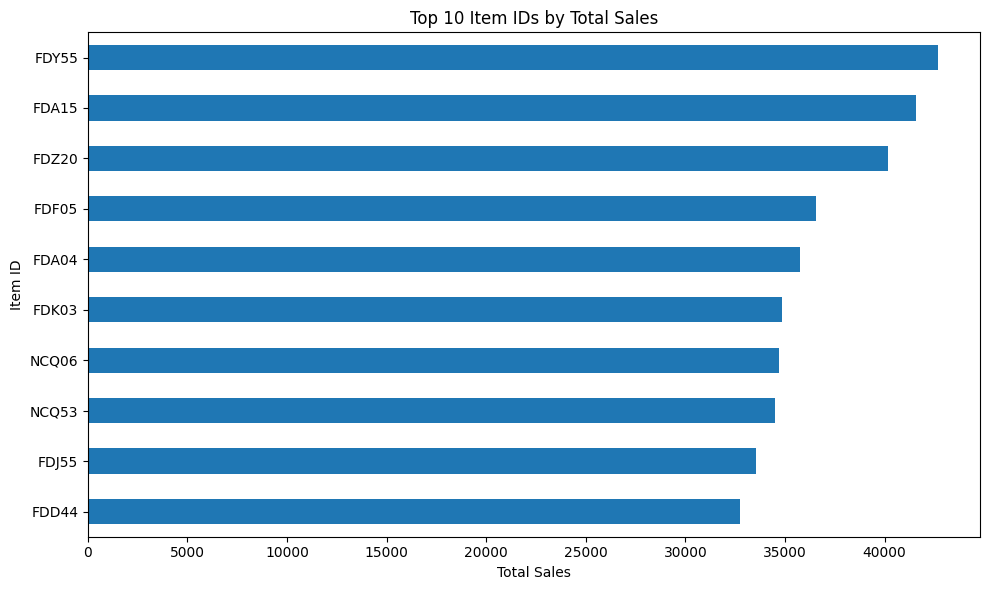

In [30]:
top_10 = (
    processed_df.groupby("Item_Identifier")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
top_10.plot(kind="barh")
plt.title("Top 10 Item IDs by Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Item ID")
plt.tight_layout()
plt.savefig("../visuals/06_top_10_items_by_sales.png", dpi=300, bbox_inches="tight")
plt.show()

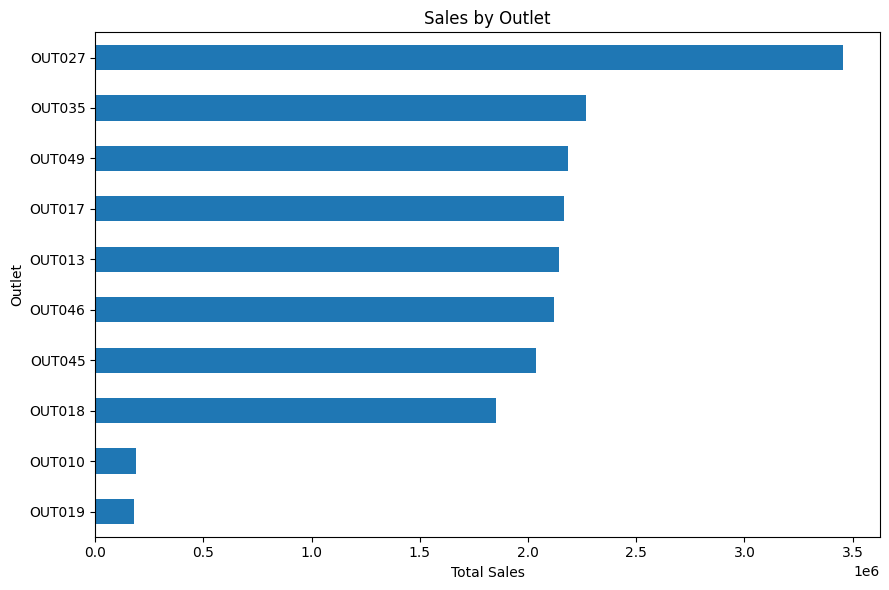

In [31]:
sales_by_outlet = (
    processed_df.groupby("Outlet_Identifier")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 6))
sales_by_outlet.plot(kind="barh")
plt.title("Sales by Outlet")
plt.xlabel("Total Sales")
plt.ylabel("Outlet")
plt.tight_layout()
plt.savefig("../visuals/07_sales_by_outlet.png", dpi=300, bbox_inches="tight")
plt.show()

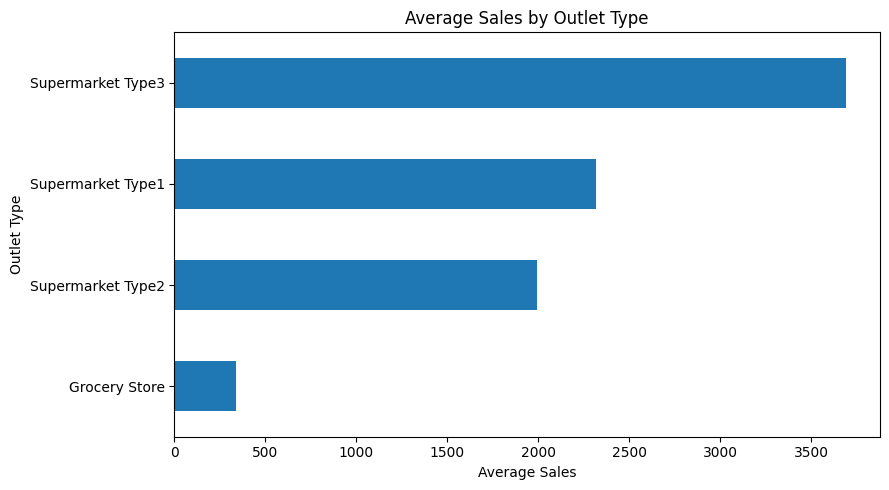

In [32]:
avg_sales_by_outlet_type = (
    processed_df.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))
avg_sales_by_outlet_type.plot(kind="barh")
plt.title("Average Sales by Outlet Type")
plt.xlabel("Average Sales")
plt.ylabel("Outlet Type")
plt.tight_layout()
plt.savefig("../visuals/08_avg_sales_by_outlet_type.png", dpi=300, bbox_inches="tight")
plt.show()

In [33]:
from pathlib import Path

visuals_dir = PROJECT_ROOT / "visuals"

png_files = sorted(visuals_dir.glob("*.png"))

print(f"Total PNG files: {len(png_files)}")

for file in png_files:
    size_kb = file.stat().st_size / 1024
    print(f"{file.name} | {size_kb:.1f} KB")

Total PNG files: 8
01_sales_by_item_type.png | 144.8 KB
02_sales_by_outlet_type.png | 88.6 KB
03_sales_by_location.png | 60.3 KB
04_sales_by_fat_content.png | 57.4 KB
05_sales_by_establishment_year.png | 133.9 KB
06_top_10_items_by_sales.png | 93.2 KB
07_sales_by_outlet.png | 95.3 KB
08_avg_sales_by_outlet_type.png | 97.6 KB


In [34]:
expected_files = [
    "01_sales_by_item_type.png",
    "02_sales_by_outlet_type.png",
    "03_sales_by_location.png",
    "04_sales_by_fat_content.png",
    "05_sales_by_establishment_year.png",
    "06_top_10_items_by_sales.png",
    "07_sales_by_outlet.png",
    "08_avg_sales_by_outlet_type.png"
]

actual_files = {file.name for file in png_files}

print("\nMissing files:")
print(set(expected_files) - actual_files)

print("\nUnexpected files:")
print(actual_files - set(expected_files))


Missing files:
set()

Unexpected files:
set()


In [35]:
# Key business percentages

total_sales = processed_df["Item_Outlet_Sales"].sum()

low_fat_sales = processed_df.loc[
    processed_df["Item_Fat_Content"] == "Low Fat",
    "Item_Outlet_Sales"
].sum()

tier_3_sales = processed_df.loc[
    processed_df["Outlet_Location_Type"] == "Tier 3",
    "Item_Outlet_Sales"
].sum()

supermarket_1_sales = processed_df.loc[
    processed_df["Outlet_Type"] == "Supermarket Type1",
    "Item_Outlet_Sales"
].sum()

grocery_sales = processed_df.loc[
    processed_df["Outlet_Type"] == "Grocery Store",
    "Item_Outlet_Sales"
].sum()

top_item_type = (
    processed_df.groupby("Item_Type")["Item_Outlet_Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(f"Low Fat sales share: {low_fat_sales / total_sales * 100:.2f}%")
print(f"Tier 3 sales share: {tier_3_sales / total_sales * 100:.2f}%")
print(f"Supermarket Type1 sales share: {supermarket_1_sales / total_sales * 100:.2f}%")
print(f"Grocery Store sales share: {grocery_sales / total_sales * 100:.2f}%")

print("\nTop 5 Item Types:")
print(top_item_type.head(5))

print("\nBottom 5 Item Types:")
print(top_item_type.tail(5))

Low Fat sales share: 64.03%
Tier 3 sales share: 41.08%
Supermarket Type1 sales share: 69.48%
Grocery Store sales share: 1.98%

Top 5 Item Types:
Item_Type
Fruits and Vegetables    2.820060e+06
Snack Foods              2.732786e+06
Household                2.055494e+06
Frozen Foods             1.825735e+06
Dairy                    1.522594e+06
Name: Item_Outlet_Sales, dtype: float64

Bottom 5 Item Types:
Item_Type
Hard Drinks      457793.4272
Starchy Foods    351401.2504
Others           325517.6096
Breakfast        232298.9516
Seafood          148868.2194
Name: Item_Outlet_Sales, dtype: float64


In [36]:
outlet_type_analysis = (
    processed_df.groupby("Outlet_Type")
    .agg(
        Total_Sales=("Item_Outlet_Sales", "sum"),
        Average_Sales=("Item_Outlet_Sales", "mean"),
        Records=("Item_Outlet_Sales", "size")
    )
)

outlet_type_analysis["Sales_Share_%"] = (
    outlet_type_analysis["Total_Sales"] / total_sales * 100
)

outlet_type_analysis["Avg_Sales_vs_Overall_%"] = (
    outlet_type_analysis["Average_Sales"] /
    processed_df["Item_Outlet_Sales"].mean() * 100
)

print(outlet_type_analysis.sort_values("Total_Sales", ascending=False))

                    Total_Sales  Average_Sales  Records  Sales_Share_%   
Outlet_Type                                                              
Supermarket Type1  1.291734e+07    2316.181148     5577      69.481228  \
Supermarket Type3  3.453926e+06    3694.038558      935      18.578359   
Supermarket Type2  1.851823e+06    1995.498739      928       9.960789   
Grocery Store      3.680343e+05     339.828500     1083       1.979623   

                   Avg_Sales_vs_Overall_%  
Outlet_Type                                
Supermarket Type1              106.184061  
Supermarket Type3              169.351182  
Supermarket Type2               91.482551  
Grocery Store                   15.579252  


In [37]:
item_type_analysis = (
    processed_df.groupby("Item_Type")
    .agg(
        Total_Sales=("Item_Outlet_Sales", "sum"),
        Average_Sales=("Item_Outlet_Sales", "mean"),
        Records=("Item_Outlet_Sales", "size"),
        Average_MRP=("Item_MRP", "mean")
    )
)

item_type_analysis["Sales_Share_%"] = (
    item_type_analysis["Total_Sales"] / total_sales * 100
)

print(
    item_type_analysis
    .sort_values("Total_Sales", ascending=False)
    .round(2)
)

                       Total_Sales  Average_Sales  Records  Average_MRP   
Item_Type                                                                 
Fruits and Vegetables   2820059.82        2289.01     1232       144.58  \
Snack Foods             2732786.09        2277.32     1200       146.19   
Household               2055493.71        2258.78      910       149.42   
Frozen Foods            1825734.79        2132.87      856       138.50   
Dairy                   1522594.05        2232.54      682       148.50   
Canned                  1444151.49        2225.19      649       139.76   
Baking Goods            1265525.34        1952.97      648       126.38   
Health and Hygiene      1045200.14        2010.00      520       130.82   
Meat                     917565.61        2158.98      425       139.88   
Soft Drinks              892897.72        2006.51      445       131.49   
Breads                   553237.19        2204.13      251       140.95   
Hard Drinks              

In [38]:
location_analysis = (
    processed_df.groupby("Outlet_Location_Type")
    .agg(
        Total_Sales=("Item_Outlet_Sales", "sum"),
        Average_Sales=("Item_Outlet_Sales", "mean"),
        Records=("Item_Outlet_Sales", "size")
    )
)

location_analysis["Sales_Share_%"] = (
    location_analysis["Total_Sales"] / total_sales * 100
)

location_analysis["Avg_Sales_vs_Overall_%"] = (
    location_analysis["Average_Sales"] /
    processed_df["Item_Outlet_Sales"].mean() * 100
)

print(location_analysis.sort_values("Total_Sales", ascending=False).round(2))

                      Total_Sales  Average_Sales  Records  Sales_Share_%   
Outlet_Location_Type                                                       
Tier 3                 7636752.63        2279.63     3350          41.08  \
Tier 2                 6472313.71        2323.99     2785          34.81   
Tier 1                 4482059.07        1876.91     2388          24.11   

                      Avg_Sales_vs_Overall_%  
Outlet_Location_Type                          
Tier 3                                104.51  
Tier 2                                106.54  
Tier 1                                 86.05  


In [39]:
print("========== FINAL INSIGHT VALIDATION ==========")

print(f"Total Sales: {total_sales:,.2f}")
print(f"Supermarket Type1 Share: {outlet_type_analysis.loc['Supermarket Type1', 'Sales_Share_%']:.2f}%")
print(f"Supermarket Type3 Avg Sales: {outlet_type_analysis.loc['Supermarket Type3', 'Average_Sales']:,.2f}")
print(f"Tier 2 + Tier 3 Share: {location_analysis.loc[['Tier 2', 'Tier 3'], 'Sales_Share_%'].sum():.2f}%")
print(f"Top 3 Item Types Share: {item_type_analysis.sort_values('Total_Sales', ascending=False).head(3)['Sales_Share_%'].sum():.2f}%")
print(f"Grocery Store Share: {outlet_type_analysis.loc['Grocery Store', 'Sales_Share_%']:.2f}%")
print(f"Grocery Store Avg Sales: {outlet_type_analysis.loc['Grocery Store', 'Average_Sales']:,.2f}")

========== FINAL INSIGHT VALIDATION ==========
Total Sales: 18,591,125.41
Supermarket Type1 Share: 69.48%
Supermarket Type3 Avg Sales: 3,694.04
Tier 2 + Tier 3 Share: 75.89%
Top 3 Item Types Share: 40.92%
Grocery Store Share: 1.98%
Grocery Store Avg Sales: 339.83
